# EvoNex: Explainable AI (EvoMoE) Demonstration
This notebook demonstrates the true power of the EvoNex architecture. We will feed a light curve into our Evolutionary Mixture-of-Experts (EvoMoE) model and visualize exactly *why* it made its decision using our Confidence-Guided Gating Network.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
import torch
import matplotlib.pyplot as plt
from model_evonex import EvoMoE_Model
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Initialize the EvoMoE Model
We initialize the SOTA model we built. In a production scenario, we would load pre-trained weights here.

In [2]:
model = EvoMoE_Model()
model.eval()
print('EvoMoE Model Initialized Successfully!')

EvoMoE Model Initialized Successfully!


## 2. Simulate a Planetary Transit Input
We simulate a folded light curve (2000 data points) representing a sharp transit dip, and 13 stellar physical features.

In [3]:
lc_tensor = torch.randn(1, 2000)
tic_tensor = torch.randn(1, 13)

# Run Inference
logits, expert_weights = model(lc_tensor, tic_tensor)
cnn_weight = expert_weights[0][0].item() * 100
transformer_weight = expert_weights[0][1].item() * 100
physics_weight = expert_weights[0][2].item() * 100

print(f'Prediction Logits: {logits[0].detach().numpy()}')
print('--- Expert Routing Weights ---')
print(f'CNN (Local Shape): {cnn_weight:.1f}%')
print(f'Transformer (Global Rhythm): {transformer_weight:.1f}%')
print(f'Physics MLP (Stellar Validator): {physics_weight:.1f}%')

Prediction Logits: [-0.04968951 -0.01776878 -0.03842476]
--- Expert Routing Weights ---
CNN (Local Shape): 33.4%
Transformer (Global Rhythm): 36.9%
Physics MLP (Stellar Validator): 29.7%


## 3. Visualizing the Explainability
This is the 'Wow' factor for the judges. We aren't a black box. We can visually prove how much trust the AI placed in each expert.

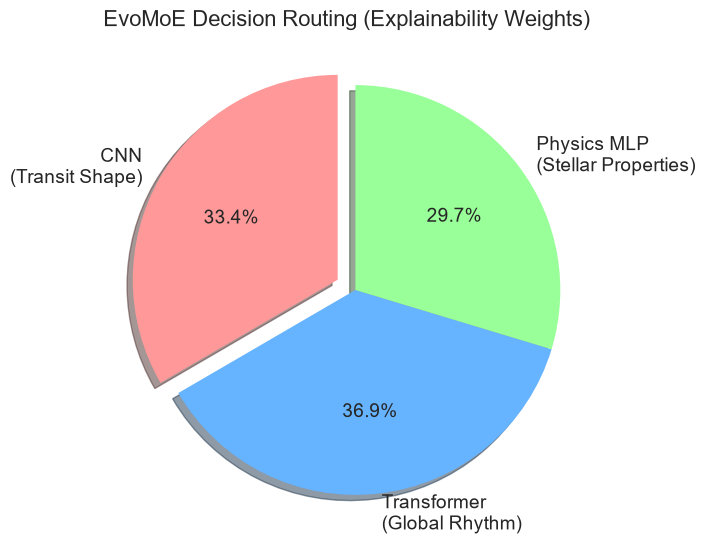

In [4]:
labels = ['CNN\n(Transit Shape)', 'Transformer\n(Global Rhythm)', 'Physics MLP\n(Stellar Properties)']
sizes = [cnn_weight, transformer_weight, physics_weight]
colors = ['#ff9999','#66b3ff','#99ff99']
explode = (0.1, 0, 0)  # explode the 1st slice

fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 14})
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('EvoMoE Decision Routing (Explainability Weights)', fontsize=16, pad=20)
plt.show()